# MorphemeOrigin train-and-predict workflow

This notebook trains or downloads the model, runs predictions on the laws file and then makes a few simple yearly statistics.


## Setup

First I set paths, helper commands and model configuration.


In [ ]:
from pathlib import Path
import shutil
import subprocess
import urllib.request
import sys

WORKSPACE = Path.cwd()

def find_existing_repo_dir(start: Path) -> Path | None:
    for candidate in (start, *start.parents):
        if (candidate / 'src').exists() and (candidate / 'requirements.txt').exists():
            return candidate
    return None

REPO_GIT_URL = 'git@github.com:ampapacek/MorphemeOrigin.git'
REPO_HTTPS_URL = 'https://github.com/ampapacek/MorphemeOrigin.git'
REPO_DIR = find_existing_repo_dir(WORKSPACE) or (WORKSPACE / 'MorphemeOrigin')
VENV_DIR = WORKSPACE / '.venv'
SYSTEM_PYTHON_BIN = Path(sys.executable)
PYTHON_BIN = VENV_DIR / 'bin' / 'python'
TRAIN_FILE = REPO_DIR / 'data' / 'annotations' / 'train.tsv'
TARGET_FILE = WORKSPACE / 'laws_in_years_annotation.tsv'
TARGET_DOWNLOAD_URL = 'https://ufallab.ms.mff.cuni.cz/~papacek/etymology/laws_in_years_annotation.tsv'
DEFAULT_MODEL_FILENAME = 'MorphClassifier_mlp_30_extend_train_multi_label.pkl'
DEFAULT_MODEL_DOWNLOAD_URL = f'https://ufallab.ms.mff.cuni.cz/~papacek/etymology/{DEFAULT_MODEL_FILENAME}'
MODEL_DIR = WORKSPACE / 'trained_models'
PREDICTIONS_DIR = WORKSPACE / 'predictions'
RUNNER_SCRIPT_CANDIDATES = [
    WORKSPACE / 'train_predict_runner.py',
    REPO_DIR / 'legal_corpus_analysis' / 'train_predict_runner.py',
    REPO_DIR / 'train_predict_runner.py',
]
RUNNER_SCRIPT = next((path for path in RUNNER_SCRIPT_CANDIDATES if path.exists()), RUNNER_SCRIPT_CANDIDATES[1])

WORKSPACE.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

def run(cmd, cwd=None, check=True):
    print('Running:')
    print('>>>', ' '.join(str(part) for part in cmd))
    return subprocess.run(cmd, cwd=cwd, check=check)


In [3]:
# Model configuration
CLASSIFIER_TYPE = 'mlp'  # 'mlp', 'svm', 'lr'
MLP_HIDDEN_SIZE = 30
MLP_ENSEMBLE_SIZE = 1
SVM_C = 1.0 # just if svm selected
SVM_KERNEL = 'rbf' # just if svm selected
MULTI_LABEL = True # preadict each language separately
EXTEND_TRAIN = True # use data from CzEtyL
RANDOM_STATE = 34867991
MIN_LABEL_FREQ = 2
MODEL_NAME = ''  # optional override

def make_model_stem():
    if MODEL_NAME:
        return MODEL_NAME
    stem = CLASSIFIER_TYPE.upper()
    if CLASSIFIER_TYPE == 'mlp':
        stem += f'_{MLP_HIDDEN_SIZE}'
        if MLP_ENSEMBLE_SIZE > 1:
            stem += f'_ensemble{MLP_ENSEMBLE_SIZE}'
    if MULTI_LABEL:
        stem += '_multi_label'
    if EXTEND_TRAIN:
        stem += '_extend_train'
    return stem

MODEL_STEM = make_model_stem()
DEFAULT_PRETRAINED_SELECTED = (
    CLASSIFIER_TYPE == 'mlp'
    and MLP_HIDDEN_SIZE == 30
    and MLP_ENSEMBLE_SIZE == 1
    and MULTI_LABEL
    and EXTEND_TRAIN
    and MIN_LABEL_FREQ == 2
)
MODEL_FILENAME = DEFAULT_MODEL_FILENAME if DEFAULT_PRETRAINED_SELECTED else f'{MODEL_STEM}.pkl'
MODEL_PATH = MODEL_DIR / MODEL_FILENAME
MODEL_DOWNLOAD_URL = DEFAULT_MODEL_DOWNLOAD_URL if DEFAULT_PRETRAINED_SELECTED else ''
TARGET_STEM = TARGET_FILE.stem
PREDICTIONS_PATH = PREDICTIONS_DIR / f'{MODEL_STEM}_{TARGET_STEM}_predictions.tsv'

print('Workspace:', WORKSPACE)
print('Repo dir :', REPO_DIR)
print('Model    :', MODEL_PATH)
print('Target   :', TARGET_FILE)
print('Output   :', PREDICTIONS_PATH)
if DEFAULT_PRETRAINED_SELECTED and MODEL_DOWNLOAD_URL:
    print('Will try download pretrained model from:', MODEL_DOWNLOAD_URL)



Workspace: /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis
Repo dir : /Users/ampapacek/MorphOrigin/MorphemeOrigin
Model    : /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/trained_models/MorphClassifier_mlp_30_extend_train_multi_label.pkl
Target   : /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/laws_in_years_annotation.tsv
Output   : /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/MLP_30_multi_label_extend_train_laws_in_years_annotation_predictions.tsv
Will try download pretrained model from: https://ufallab.ms.mff.cuni.cz/~papacek/etymology/MorphClassifier_mlp_30_extend_train_multi_label.pkl


In [4]:
repo_ready = (
    REPO_DIR.exists()
    and (REPO_DIR / '.git').exists()
    and (REPO_DIR / 'requirements.txt').exists()
)

if repo_ready:
    print(f'Repository already present: {REPO_DIR}')
else:
    if REPO_DIR.exists():
        print(f'Removing incomplete repository directory: {REPO_DIR}')
        shutil.rmtree(REPO_DIR)
    try:
        run(['git', 'clone', REPO_HTTPS_URL, str(REPO_DIR)], cwd=WORKSPACE)
    except subprocess.CalledProcessError:
        if REPO_DIR.exists():
            shutil.rmtree(REPO_DIR)
        run(['git', 'clone', REPO_GIT_URL, str(REPO_DIR)], cwd=WORKSPACE)


Repository already present: /Users/ampapacek/MorphOrigin/MorphemeOrigin


In [ ]:
if 'google.colab' in sys.modules:
    PYTHON_BIN = SYSTEM_PYTHON_BIN
    print('Running in Colab, using notebook Python:', PYTHON_BIN)
else:
    if not PYTHON_BIN.exists():
        base_python = shutil.which('python3.12') or shutil.which('python3.11') or shutil.which('python3')
        if base_python is None:
            raise RuntimeError('No python3 interpreter found for virtual environment creation.')
        try:
            run([base_python, '-m', 'venv', str(VENV_DIR)], cwd=REPO_DIR)
        except subprocess.CalledProcessError:
            print('Could not create a virtual environment, using the current notebook Python instead.')
            PYTHON_BIN = SYSTEM_PYTHON_BIN
    else:
        print('Virtual environment already present:', PYTHON_BIN)

run([str(PYTHON_BIN), '-m', 'pip', 'install', '-r', 'requirements.txt'], cwd=REPO_DIR)
print('Environment ready:', PYTHON_BIN)


## Dataset
To download the source law texts from e-Sbírka, uncomment and run the command below.

After that, you can build the sampled per-year corpus with the helper script shown in the next commented cell.
The plain-text corpus should keep `# Year YYYY` divider lines and then one sentence per line, as in `sentences_laws1918-2026_1000_wpy.txt`.
To use the corpus in this notebook, morphological segmentation and morph-type classification must then be performed separately. The final file used below (`laws_in_years_annotation.tsv`) should contain a sentence line, an indented word line, and doubly indented morph lines with labels such as `R`, `D`, and `I`.
The conversion from segmented text to this annotation format is not included in this tracked package and has to be done externally before running the prediction pipeline.

These steps are optional in the default workflow because the prepared target file can be downloaded directly.


In [6]:
# run([
#     str(PYTHON_BIN),
#     'download_esbirka_laws.py',
#     '--years', '1918-2026',
#     '--include-kind', 'zakon',
#     '--only-new-laws',
#     '--output-dir', 'data_laws_1918_2026',
#     '--verbose',
# ], cwd=WORKSPACE)


In [7]:
# run([
#     str(PYTHON_BIN),
#     'build_law_corpus_by_year.py',
#     '--input-dir', 'data_laws_1918_2026',
#     '--words-per-year', '1000',
#     '--sample-by', 'sentence',
#     '--seed', '42',
#     '--exclude-punctuation',
#     '--output-file', 'sentences_laws1918-2026_1000_wpy.txt',
# ], cwd=WORKSPACE)


In [8]:
# Morphological segmentation and morph-type classification are required before prediction.
# The resulting annotation file is expected at TARGET_FILE in the indented MorphOrigin format.


In [9]:
if not TARGET_FILE.exists():
    try:
        print(f'Downloading {TARGET_DOWNLOAD_URL} -> {TARGET_FILE}')
        urllib.request.urlretrieve(TARGET_DOWNLOAD_URL, TARGET_FILE)
    except Exception as exc:
        raise RuntimeError(f'Could not download {TARGET_FILE.name}: {exc}')
else:
    print(f'File already present: {TARGET_FILE}')


## Run model

Here the notebook uses the external runner script and executes the prediction pipeline.


In [10]:
if not RUNNER_SCRIPT.exists():
    raise FileNotFoundError(f'Runner script not found: {RUNNER_SCRIPT}')
print(f'Using runner script: {RUNNER_SCRIPT}')


Using runner script: /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/train_predict_runner.py


In [11]:
cmd = [
    str(PYTHON_BIN),
    str(RUNNER_SCRIPT),
    str(WORKSPACE),
    str(REPO_DIR),
    str(TRAIN_FILE),
    str(TARGET_FILE),
    str(MODEL_PATH),
    str(PREDICTIONS_PATH),
]
if MODEL_DOWNLOAD_URL:
    cmd.extend(['--model-download-url', MODEL_DOWNLOAD_URL])
cmd.extend(['--classifier-type', CLASSIFIER_TYPE])
cmd.extend(['--mlp-hidden-size', str(MLP_HIDDEN_SIZE)])
cmd.extend(['--mlp-ensemble-size', str(MLP_ENSEMBLE_SIZE)])
cmd.extend(['--svm-c', str(SVM_C)])
cmd.extend(['--svm-kernel', SVM_KERNEL])
cmd.extend(['--random-state', str(RANDOM_STATE)])
cmd.extend(['--min-label-freq', str(MIN_LABEL_FREQ)])
if MULTI_LABEL:
    cmd.append('--multi-label')
if EXTEND_TRAIN:
    cmd.append('--extend-train')
if MODEL_NAME:
    cmd.extend(['--model-name', MODEL_NAME])
run(cmd, cwd=WORKSPACE)


Running:
>>> /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/.venv/bin/python /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/train_predict_runner.py /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis /Users/ampapacek/MorphOrigin/MorphemeOrigin /Users/ampapacek/MorphOrigin/MorphemeOrigin/data/annotations/train.tsv /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/laws_in_years_annotation.tsv /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/trained_models/MorphClassifier_mlp_30_extend_train_multi_label.pkl /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/MLP_30_multi_label_extend_train_laws_in_years_annotation_predictions.tsv --model-download-url https://ufallab.ms.mff.cuni.cz/~papacek/etymology/MorphClassifier_mlp_30_extend_train_multi_label.pkl --classifier-type mlp --mlp-hidden-size 30 --mlp-ensemble-size 1 --svm-c 1.0 --svm-kernel rbf --random-state 34867991 --min-label-f

/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Predictions completed
Saved predictions to /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/MLP_30_multi_label_extend_train_laws_in_years_annotation_predictions.tsv


CompletedProcess(args=['/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/.venv/bin/python', '/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/train_predict_runner.py', '/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis', '/Users/ampapacek/MorphOrigin/MorphemeOrigin', '/Users/ampapacek/MorphOrigin/MorphemeOrigin/data/annotations/train.tsv', '/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/laws_in_years_annotation.tsv', '/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/trained_models/MorphClassifier_mlp_30_extend_train_multi_label.pkl', '/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/MLP_30_multi_label_extend_train_laws_in_years_annotation_predictions.tsv', '--model-download-url', 'https://ufallab.ms.mff.cuni.cz/~papacek/etymology/MorphClassifier_mlp_30_extend_train_multi_label.pkl', '--classifier-type', 'mlp', '--mlp-hidden-size', '30', '--mlp-ensemble-size', '1', '--svm-c

## Preview predictions

I print a few first non-empty blocks from the saved prediction file.


In [12]:
print(PREDICTIONS_PATH)
shown = 0
current_block = []
with open(PREDICTIONS_PATH, 'r', encoding='utf-8') as handle:
    for line in handle:
        if line.strip():
            current_block.append(line.rstrip())
            continue
        if current_block:
            print('\n'.join(current_block))
            print()
            shown += 1
            current_block = []
            if shown >= 3:
                break
    if shown < 3 and current_block:
        print('\n'.join(current_block))


/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/MLP_30_multi_label_extend_train_laws_in_years_annotation_predictions.tsv
# Year 1918

Šlechtictví a řády jakož i veškerá z nich plynoucí práva se zrušují rovněž tak tituly pokud byly udělovány jako pouhá vyznamenání
    Šlechtictví
        Šlechtic	R	ces
        tv	D	ces
        í	I	ces
    a
        a	R	eng
    řády
        řá	D	ces
        d	D	ces
        y	I	ces
    jakož
        jakož	R	ces
    i
        i	D	ces
    veškerá
        vešker	R	ces
        á	I	ces
    z
        z	D	ces
    nich
        nich	R	ces
    plynoucí
        plynouc	R	ces,pol
        í	I	ces
    práva
        práv	R	ces
        a	I	ces
    se
        s	D	ces
        e	I	ces
    zrušují
        zrušuj	R	ces
        í	I	ces
    rovněž
        rovněž	R	ces
    tak
        tak	D	ces
    tituly
        titul	R	lat
        y	I	ces
    pokud
        po	D	ces
        kud	R	ces
    byly
        byl	R	ces
        y	I	ces
    udělovány
        

## Yearly statistics

In this part I read the saved prediction file, use the preserved `# Year` sections, print a few compact tables and draw plots for the time trends.


The tables below show three views: the top predicted languages, the native vs borrowed split, and a small summary of borrowed-language diversity by year.


Matplotlib is building the font cache; this may take a moment.


Language table legend: all_n = all predicted labels, _n = count, _sh = share in that year.
/Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/yearly_top_languages_annotation.tsv
year  all_n  ces_n  ces_sh  lat_n  lat_sh  eng_n  eng_sh  deu_n  deu_sh  fra_n  fra_sh  ell_n  ell_sh  pol_n  pol_sh  ita_n  ita_sh  fro_n  fro_sh  gmh_n  gmh_sh
----  -----  -----  ------  -----  ------  -----  ------  -----  ------  -----  ------  -----  ------  -----  ------  -----  ------  -----  ------  -----  ------
1918   2163   1994  0.9219     77  0.0356     32  0.0148     12  0.0055     11  0.0051     12  0.0055      2  0.0009      2  0.0009      9  0.0042     11  0.0051
1919   2823   2482  0.8792    119  0.0422     48  0.0170     53  0.0188     30  0.0106     26  0.0092     11  0.0039     12  0.0043     22  0.0078     12  0.0043
1920   2731   2518  0.9220     97  0.0355     28  0.0103     27  0.0099     23  0.0084      6  0.0022     21  0.0077      2  0.0007      1  0.0004 

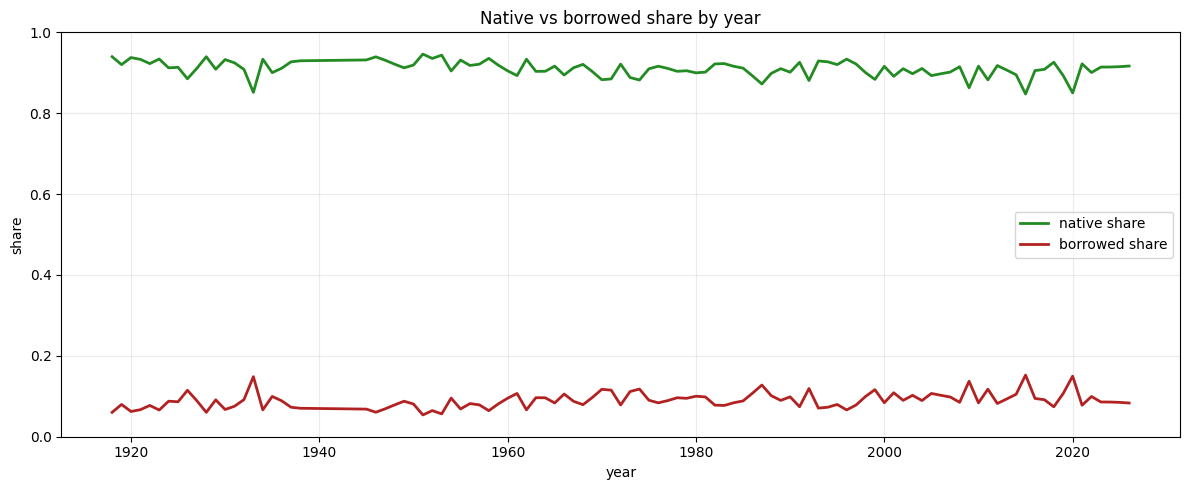

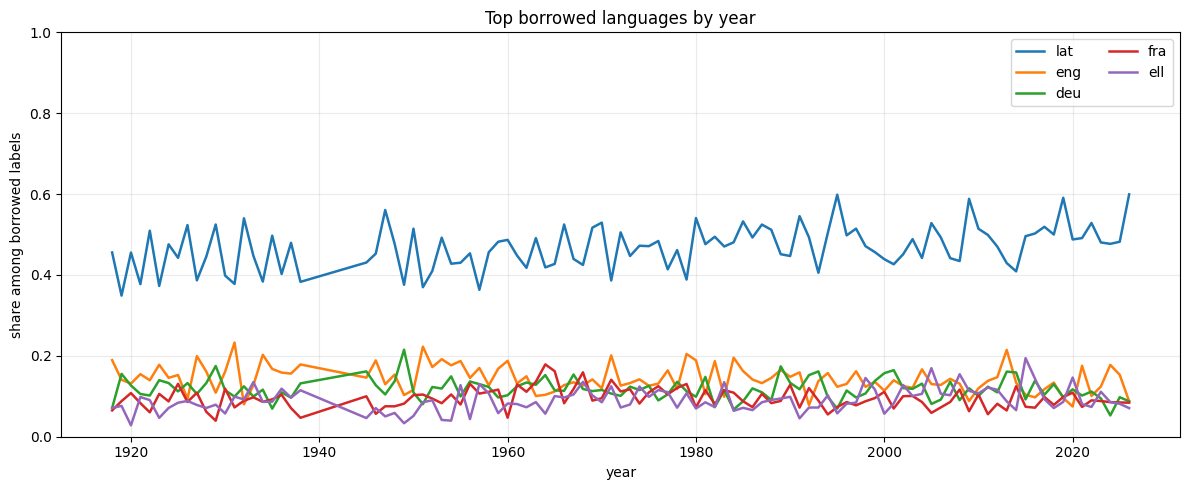

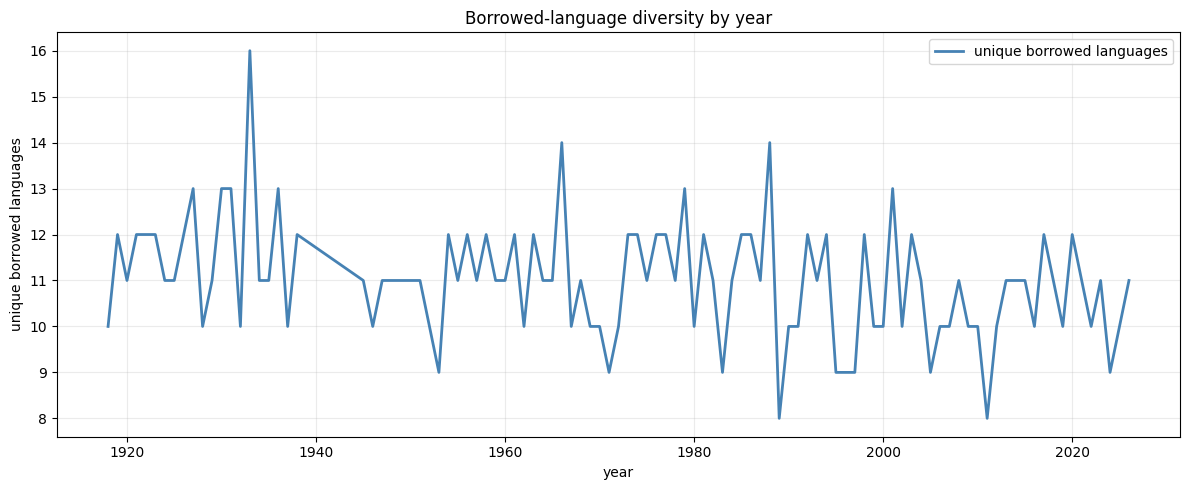

Native/borrowed plot saved to /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/yearly_native_borrowed_annotation.png
Borrowed-language plot saved to /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/yearly_top_borrowed_languages_annotation.png
Borrowed-focus plot saved to /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/yearly_borrowed_focus_annotation.png


In [13]:
from collections import Counter, defaultdict
import csv
import os
from pathlib import Path
import subprocess
import sys

MPL_DIR = WORKSPACE / '.mplconfig'
MPL_DIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_DIR))

try:
    import matplotlib.pyplot as plt
except ImportError:
    subprocess.run([str(PYTHON_BIN), '-m', 'pip', 'install', 'matplotlib'], check=True)
    import matplotlib.pyplot as plt

DATASET_TAG = TARGET_FILE.stem
if DATASET_TAG.startswith('laws_in_years_'):
    DATASET_TAG = DATASET_TAG[len('laws_in_years_'):]

LANGUAGE_STATS_PATH = PREDICTIONS_DIR / f'yearly_top_languages_{DATASET_TAG}.tsv'
NATIVE_BORROWED_STATS_PATH = PREDICTIONS_DIR / f'yearly_native_borrowed_{DATASET_TAG}.tsv'
BORROWED_FOCUS_PATH = PREDICTIONS_DIR / f'yearly_borrowed_focus_{DATASET_TAG}.tsv'
SUMMARY_PATH = PREDICTIONS_DIR / f'yearly_dataset_overview_{DATASET_TAG}.tsv'
NATIVE_BORROWED_PLOT_PATH = PREDICTIONS_DIR / f'yearly_native_borrowed_{DATASET_TAG}.png'
BORROWED_LANG_PLOT_PATH = PREDICTIONS_DIR / f'yearly_top_borrowed_languages_{DATASET_TAG}.png'
BORROWED_FOCUS_PLOT_PATH = PREDICTIONS_DIR / f'yearly_borrowed_focus_{DATASET_TAG}.png'

TOP_K = 10
TOP_BORROWED_K = 5

year_language_counts = defaultdict(Counter)
year_total_labels = defaultdict(int)
year_native_counts = defaultdict(int)
year_borrowed_counts = defaultdict(int)
year_borrowed_language_counts = defaultdict(Counter)
global_language_counts = Counter()
global_borrowed_language_counts = Counter()
sentence_count_by_year = Counter()

current_year = None
current_sentence_has_morph = False
for raw_line in PREDICTIONS_PATH.read_text(encoding='utf-8').splitlines():
    line = raw_line.rstrip()
    if line.startswith('# Year'):
        current_year = int(line.split()[2])
        continue
    if line.startswith('#'):
        continue
    if not line:
        if current_sentence_has_morph and current_year is not None:
            sentence_count_by_year[current_year] += 1
        current_sentence_has_morph = False
        continue
    if not raw_line.startswith((' ', '\t')):
        current_sentence_has_morph = False
        continue
    if line.startswith('    '):
        parts = line.strip().split('\t')
        if len(parts) >= 3 and current_year is not None:
            labels = [label.strip() for label in parts[2].split(',') if label.strip()]
            if labels:
                current_sentence_has_morph = True
                if labels == ['ces']:
                    year_native_counts[current_year] += 1
                else:
                    year_borrowed_counts[current_year] += 1
                    for label in labels:
                        if label != 'ces':
                            year_borrowed_language_counts[current_year][label] += 1
                            global_borrowed_language_counts[label] += 1
                for label in labels:
                    year_language_counts[current_year][label] += 1
                    year_total_labels[current_year] += 1
                    global_language_counts[label] += 1
if current_sentence_has_morph and current_year is not None:
    sentence_count_by_year[current_year] += 1

years = sorted(year_total_labels)
top_languages = [lang for lang, _ in global_language_counts.most_common(TOP_K)]
top_borrowed_languages = [lang for lang, _ in global_borrowed_language_counts.most_common(TOP_BORROWED_K)]

with open(LANGUAGE_STATS_PATH, 'w', encoding='utf-8', newline='') as out:
    writer = csv.writer(out, delimiter='\t')
    header = ['year', 'all_n']
    for lang in top_languages:
        header.extend([f'{lang}_n', f'{lang}_sh'])
    writer.writerow(header)
    for year in years:
        total = year_total_labels[year]
        row = [year, total]
        for lang in top_languages:
            count = year_language_counts[year][lang]
            share = count / total if total else 0.0
            row.extend([count, f'{share:.4f}'])
        writer.writerow(row)

with open(NATIVE_BORROWED_STATS_PATH, 'w', encoding='utf-8', newline='') as out:
    writer = csv.writer(out, delimiter='\t')
    writer.writerow(['year', 'nat_n', 'bor_n', 'all_n', 'nat_sh', 'bor_sh'])
    for year in years:
        native = year_native_counts[year]
        borrowed = year_borrowed_counts[year]
        total = native + borrowed
        writer.writerow([year, native, borrowed, total, f'{(native / total if total else 0.0):.4f}', f'{(borrowed / total if total else 0.0):.4f}'])

with open(BORROWED_FOCUS_PATH, 'w', encoding='utf-8', newline='') as out:
    writer = csv.writer(out, delimiter='\t')
    writer.writerow(['year', 'uniq_bor', 'top_lang', 'top_n', 'top_sh'])
    for year in years:
        borrowed_total = sum(year_borrowed_language_counts[year].values())
        if borrowed_total:
            top_lang, top_n = year_borrowed_language_counts[year].most_common(1)[0]
            top_p = top_n / borrowed_total
        else:
            top_lang, top_n, top_p = '-', 0, 0.0
        writer.writerow([year, len(year_borrowed_language_counts[year]), top_lang, top_n, f'{top_p:.4f}'])

with open(SUMMARY_PATH, 'w', encoding='utf-8', newline='') as out:
    writer = csv.writer(out, delimiter='\t')
    writer.writerow(['year', 'sent_n', 'morph_n'])
    for year in years:
        writer.writerow([year, sentence_count_by_year[year], year_native_counts[year] + year_borrowed_counts[year]])

def print_tsv_table(path):
    with open(path, 'r', encoding='utf-8') as handle:
        rows = [line.rstrip('\n').split('\t') for line in handle]
    widths = [max(len(row[i]) for row in rows) for i in range(len(rows[0]))]
    for row_idx, row in enumerate(rows):
        print('  '.join(value.rjust(widths[i]) if i else value.ljust(widths[i]) for i, value in enumerate(row)))
        if row_idx == 0:
            print('  '.join('-' * width for width in widths))

print('Language table legend: all_n = all predicted labels, _n = count, _sh = share in that year.')
print(LANGUAGE_STATS_PATH)
print_tsv_table(LANGUAGE_STATS_PATH)
print()
print('Native/borrowed legend: nat = native (only ces), bor = borrowed, all_n = nat_n + bor_n, _sh = share.')
print(NATIVE_BORROWED_STATS_PATH)
print_tsv_table(NATIVE_BORROWED_STATS_PATH)
print()
print('Borrowed-focus legend: uniq_bor = number of distinct borrowed languages, top_lang = most frequent borrowed language, top_sh = its share among borrowed labels.')
print(BORROWED_FOCUS_PATH)
print_tsv_table(BORROWED_FOCUS_PATH)
print()
print('Dataset overview legend: sent_n = sentence blocks, morph_n = morph predictions in that year.')
print(SUMMARY_PATH)
print_tsv_table(SUMMARY_PATH)

native_share = [year_native_counts[y] / (year_native_counts[y] + year_borrowed_counts[y]) if (year_native_counts[y] + year_borrowed_counts[y]) else 0.0 for y in years]
borrowed_share = [year_borrowed_counts[y] / (year_native_counts[y] + year_borrowed_counts[y]) if (year_native_counts[y] + year_borrowed_counts[y]) else 0.0 for y in years]
plt.figure(figsize=(12, 5))
plt.plot(years, native_share, label='native share', color='forestgreen', linewidth=2)
plt.plot(years, borrowed_share, label='borrowed share', color='firebrick', linewidth=2)
plt.title('Native vs borrowed share by year')
plt.xlabel('year')
plt.ylabel('share')
plt.ylim(0, 1)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(NATIVE_BORROWED_PLOT_PATH, dpi=160)
plt.show()

plt.figure(figsize=(12, 5))
for lang in top_borrowed_languages:
    shares = []
    for year in years:
        total_borrowed_labels = sum(year_borrowed_language_counts[year].values())
        shares.append(year_borrowed_language_counts[year][lang] / total_borrowed_labels if total_borrowed_labels else 0.0)
    plt.plot(years, shares, label=lang, linewidth=1.8)
plt.title('Top borrowed languages by year')
plt.xlabel('year')
plt.ylabel('share among borrowed labels')
plt.ylim(0, 1)
plt.grid(True, alpha=0.25)
if top_borrowed_languages:
    plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(BORROWED_LANG_PLOT_PATH, dpi=160)
plt.show()

uniq_borrowed = [len(year_borrowed_language_counts[y]) for y in years]
plt.figure(figsize=(12, 5))
plt.plot(years, uniq_borrowed, label='unique borrowed languages', color='steelblue', linewidth=2)
plt.title('Borrowed-language diversity by year')
plt.xlabel('year')
plt.ylabel('unique borrowed languages')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(BORROWED_FOCUS_PLOT_PATH, dpi=160)
plt.show()

print(f'Native/borrowed plot saved to {NATIVE_BORROWED_PLOT_PATH}')
print(f'Borrowed-language plot saved to {BORROWED_LANG_PLOT_PATH}')
print(f'Borrowed-focus plot saved to {BORROWED_FOCUS_PLOT_PATH}')


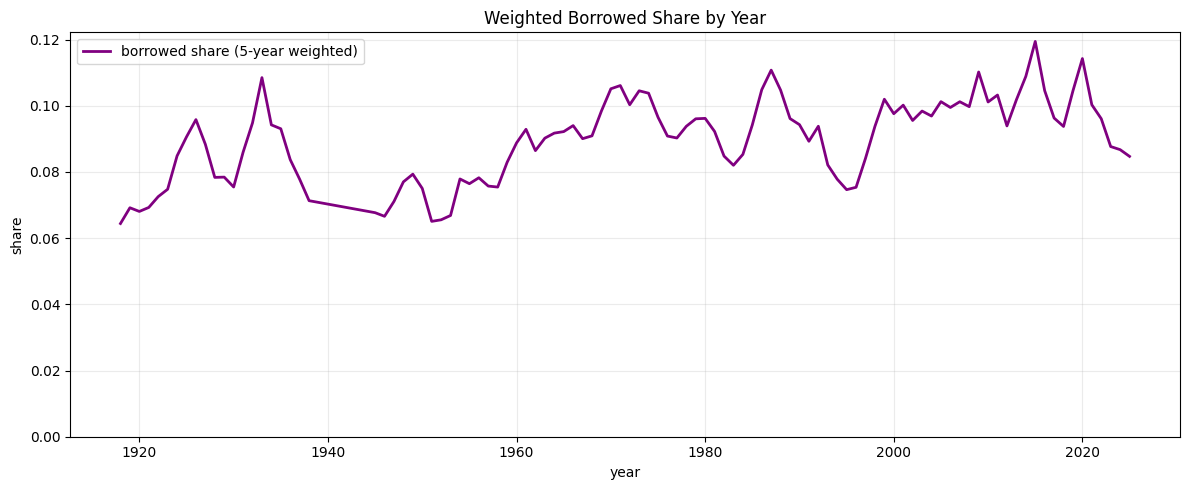

Weighted borrowed-share plot saved to /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/yearly_borrowed_weighted_annotation.png


In [14]:
import numpy as np

def weighted_moving_average(data, weights):
    """Return a centered weighted moving average with edge padding."""
    size = len(weights)
    pad_size = size // 2
    padded = np.pad(data, (pad_size, pad_size), mode='edge')

    output = []
    for i in range(len(data)):
        window = padded[i : i + size]
        avg = np.sum(window * weights) / np.sum(weights)
        output.append(avg)
    return np.array(output)

weights = np.array([0.1, 0.2, 0.4, 0.2, 0.1])
smoothed_borrowed_weighted = weighted_moving_average(borrowed_share, weights)

BORROWED_WEIGHTED_PLOT_PATH = PREDICTIONS_DIR / f'yearly_borrowed_weighted_{DATASET_TAG}.png'

plot_years = years[:-1]
plot_smoothed_borrowed_weighted = smoothed_borrowed_weighted[:-1]

plt.figure(figsize=(12, 5))
plt.plot(
    plot_years,
    plot_smoothed_borrowed_weighted,
    label='borrowed share (5-year weighted)',
    color='purple',
    linewidth=2,
)
plt.title('Weighted Borrowed Share by Year')
plt.xlabel('year')
plt.ylabel('share')
plt.ylim(bottom=0)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(BORROWED_WEIGHTED_PLOT_PATH, dpi=160)
plt.show()

print(f'Weighted borrowed-share plot saved to {BORROWED_WEIGHTED_PLOT_PATH}')


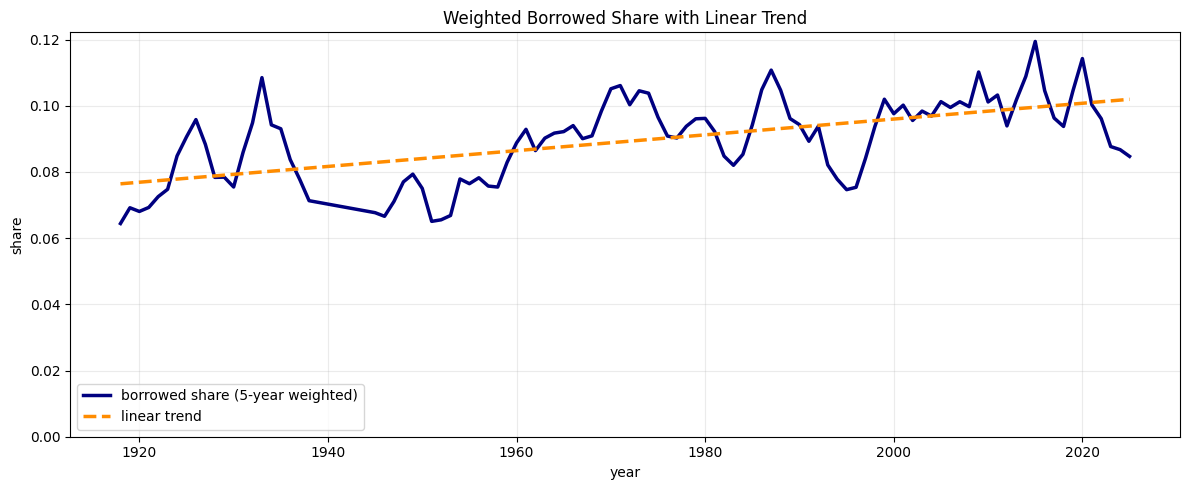

Weighted borrowed-share trend plot saved to /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/yearly_borrowed_weighted_trendline_annotation.png
Weighted linear fit slope: 0.00023862
Weighted linear fit intercept: -0.38126327


In [15]:
# Fit a linear trend line through the weighted-smoothed borrowed-share series.
weighted_fit_years = np.array(plot_years, dtype=float)
weighted_fit_values = np.array(plot_smoothed_borrowed_weighted, dtype=float)
weighted_fit_coefficients = np.polyfit(weighted_fit_years, weighted_fit_values, deg=1)
full_weighted_fit_years = np.arange(int(weighted_fit_years[0]), int(weighted_fit_years[-1]) + 1)
fitted_weighted_borrowed_share = np.polyval(weighted_fit_coefficients, full_weighted_fit_years)

BORROWED_WEIGHTED_TREND_PLOT_PATH = PREDICTIONS_DIR / f'yearly_borrowed_weighted_trendline_{DATASET_TAG}.png'

plt.figure(figsize=(12, 5))
plt.plot(
    weighted_fit_years,
    weighted_fit_values,
    label='borrowed share (5-year weighted)',
    color='navy',
    linewidth=2.5,
)
plt.plot(
    full_weighted_fit_years,
    fitted_weighted_borrowed_share,
    label='linear trend',
    color='darkorange',
    linewidth=2.5,
    linestyle='--',
)
plt.title('Weighted Borrowed Share with Linear Trend')
plt.xlabel('year')
plt.ylabel('share')
plt.ylim(bottom=0)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(BORROWED_WEIGHTED_TREND_PLOT_PATH, dpi=160)
plt.show()

print(f'Weighted borrowed-share trend plot saved to {BORROWED_WEIGHTED_TREND_PLOT_PATH}')
print(f'Weighted linear fit slope: {weighted_fit_coefficients[0]:.8f}')
print(f'Weighted linear fit intercept: {weighted_fit_coefficients[1]:.8f}')


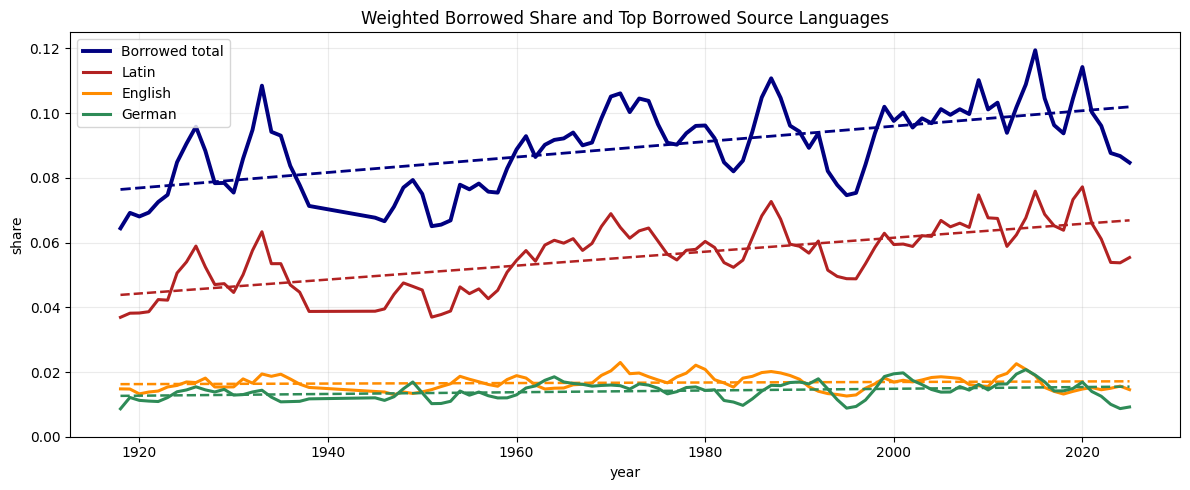

Weighted borrowed-share top-language plot saved to /Users/ampapacek/MorphOrigin/MorphemeOrigin/legal_corpus_analysis/predictions/yearly_borrowed_weighted_top3_annotation.png
Top borrowed languages: Latin, English, German


In [18]:
# Plot weighted-smoothed shares for the overall borrowed proportion and the top 3 borrowed source languages.
top_3_borrowed_languages = [lang for lang, _ in global_borrowed_language_counts.most_common(3)]
language_name_map = {
    'lat': 'Latin',
    'eng': 'English',
    'deu': 'German',
    'fra': 'French',
    'ell': 'Greek',
}

BORROWED_TOP3_WEIGHTED_PLOT_PATH = PREDICTIONS_DIR / f'yearly_borrowed_weighted_top3_{DATASET_TAG}.png'
fit_years = np.array(plot_years, dtype=float)

plt.figure(figsize=(12, 5))
plt.plot(
    plot_years,
    plot_smoothed_borrowed_weighted,
    label='Borrowed total',
    color='navy',
    linewidth=2.8,
)
overall_fit = np.polyfit(fit_years, np.array(plot_smoothed_borrowed_weighted, dtype=float), deg=1)
plt.plot(
    plot_years,
    np.polyval(overall_fit, fit_years),
    color='navy',
    linewidth=2.0,
    linestyle='--',
)

top_language_colors = ['firebrick', 'darkorange', 'seagreen']
for lang, color in zip(top_3_borrowed_languages, top_language_colors):
    yearly_language_share = [
        year_borrowed_language_counts[year][lang] / year_total_labels[year] if year_total_labels[year] else 0.0
        for year in years
    ]
    smoothed_language_share = weighted_moving_average(yearly_language_share, weights)[:-1]
    display_name = language_name_map.get(lang, lang)
    plt.plot(
        plot_years,
        smoothed_language_share,
        label=display_name,
        color=color,
        linewidth=2.2,
    )
    language_fit = np.polyfit(fit_years, np.array(smoothed_language_share, dtype=float), deg=1)
    plt.plot(
        plot_years,
        np.polyval(language_fit, fit_years),
        color=color,
        linewidth=1.8,
        linestyle='--',
    )

plt.title('Weighted Borrowed Share and Top Borrowed Source Languages')
plt.xlabel('year')
plt.ylabel('share')
plt.ylim(bottom=0)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(BORROWED_TOP3_WEIGHTED_PLOT_PATH, dpi=160)
plt.show()

print(f'Weighted borrowed-share top-language plot saved to {BORROWED_TOP3_WEIGHTED_PLOT_PATH}')
print('Top borrowed languages:', ', '.join(language_name_map.get(lang, lang) for lang in top_3_borrowed_languages))
